In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

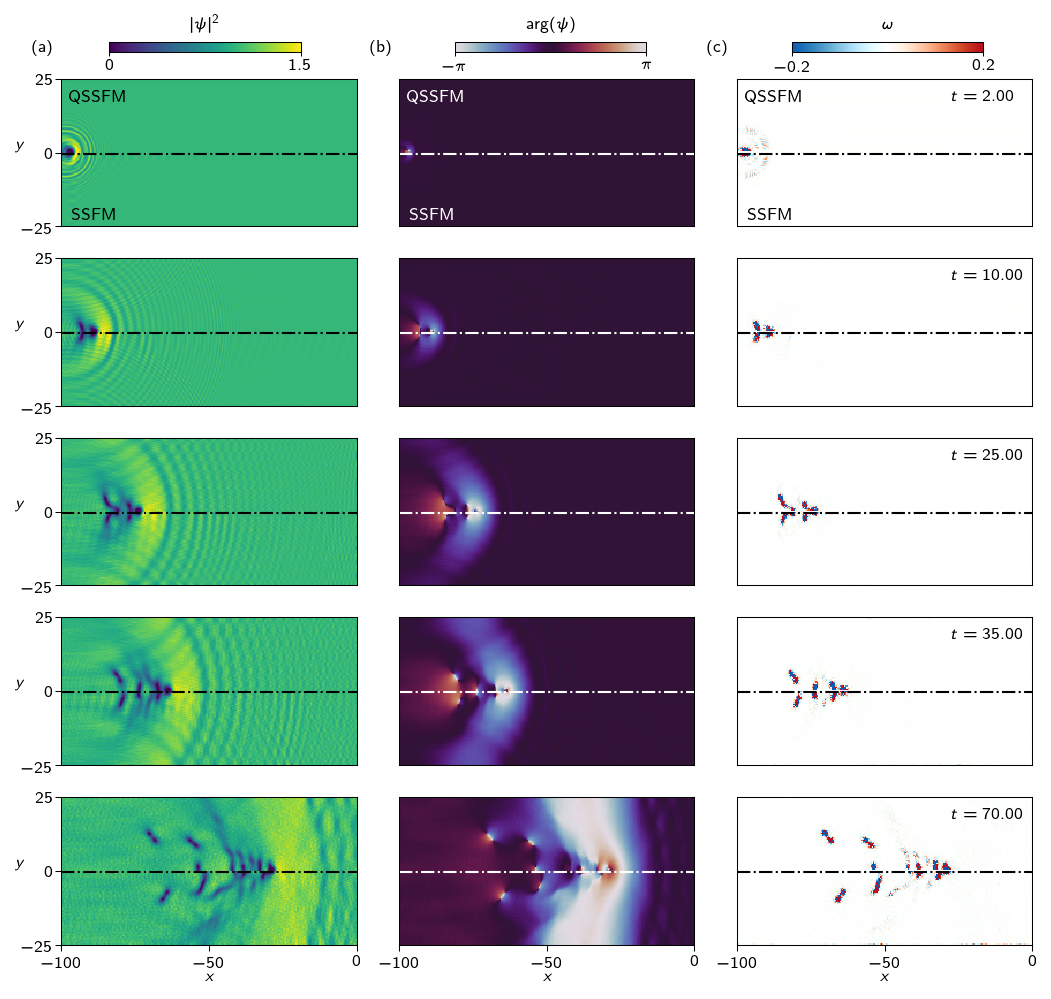

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import NullFormatter
from matplotlib.colors import LinearSegmentedColormap, hex2color
from scipy.interpolate import interp1d



data = np.load("2d-cylinder.npz")

times = data['times']
psi_ssfm = data['psi_ssfm']
psi_qssfm = data['psi_filtered_qssfm']
phase_ssfm = data['phase_ssfm']
phase_qssfm = data['phase_filtered_qssfm']
vorticity_ssfm = data['vorticity_ssfm']
vorticity_qssfm = data['vorticity_filtered_qssfm']


def ensure_3d(field, name="field"):
    field = np.asarray(field)
    if field.ndim == 2:
        field = field[None, :, :]
    elif field.ndim == 3:
        pass
    return field



def combine_half(field_qssfm, field_ssfm, name="field"):
    field_qssfm = ensure_3d(field_qssfm, name=f"{name}_qssfm")
    field_ssfm = ensure_3d(field_ssfm, name=f"{name}_ssfm")

    if field_qssfm.shape != field_ssfm.shape:
        raise ValueError(
            f"{field_qssfm.shape} vs {field_ssfm.shape}"
        )

    nt, Nx, Ny = field_ssfm.shape
    mid = Ny // 2

    field_plot = np.zeros_like(field_ssfm)
    field_plot[:, :, :mid] = field_qssfm[:, :, :mid]
    field_plot[:, :, mid:] = field_ssfm[:, :, mid:]

    return field_plot


rho_plot = combine_half(psi_qssfm, psi_ssfm, name="rho")
phase_plot = combine_half(phase_qssfm, phase_ssfm, name="phase")
vor_plot = combine_half(vorticity_qssfm, vorticity_ssfm, name="vorticity")


nt = rho_plot.shape[0]


def create_smooth_cmap(colors, name='smooth_cmap', N=256):
    rgb_colors = np.array([hex2color(c) for c in colors])
    original_nodes = np.linspace(0, 1, len(rgb_colors))
    f = interp1d(original_nodes, rgb_colors, kind='cubic', axis=0)
    new_nodes = np.linspace(0, 1, N)
    new_colors = f(new_nodes)
    new_colors = np.clip(new_colors, 0, 1)
    return LinearSegmentedColormap.from_list(name, new_colors)

cmap_BuRd = create_smooth_cmap(
    ["#0f5fb5", "#86c5e5", "#ffffff", "#f69d74", "#b80b1f"],
    name="cmap_BuRd"
)


fig_width = 18 / 2.54
fig_height = 18 / 2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 5 / 2.54 / fig_width
ax_height = 2.5 / 2.54 / fig_height


col_gap = 0.04
row_gap = 0.03


x_slice = slice(0, rho_plot.shape[1] // 2)


Nx_show = rho_plot[:, x_slice, :].shape[1]
Ny_show = rho_plot.shape[2]

x_tick_pos = np.linspace(0, Nx_show, 3)
x_tick_labels = [r'$-100$', r'$-50$', r'$0$']

y_tick_pos = np.linspace(0, Ny_show, 3)
y_tick_labels = [r'$-25$', r'$0$', r'$25$']

split_y = Ny_show // 2 - 1



top_label_left = "QSSFM"
top_label_right = "SSFM"


top_label_left_x = 0.1225
top_label_left_y = 0.825

top_label_right_x = 0.11
top_label_right_y = 0.025

top_label_fontsize = fontsize


time_label_x = 0.725
time_label_y = 0.875
time_label_fontsize = fontsize


def style_axis(
    ax,
    row_id,
    col_id,
    nrows,
    ncols,
    line_color='black',
):

    ax.axhline(y=split_y, color=line_color, linestyle='-.', linewidth=1)


    if row_id == nrows - 1:
        ax.set_xlabel(r'$x$', labelpad=0, size=fontsize)
        ax.set_xticks(x_tick_pos)
        ax.set_xticklabels(x_tick_labels)
    else:
        ax.xaxis.set_major_formatter(NullFormatter())
        ax.set_xticks([])


    if col_id == 0:
        ax.set_ylabel(r'$y$', labelpad=1, size=fontsize, rotation=0)
        ax.set_yticks(y_tick_pos)
        ax.set_yticklabels(y_tick_labels)
    else:
        ax.yaxis.set_major_formatter(NullFormatter())
        ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.tick_params(
        axis='x',
        which='major',
        direction='out',
        top=False,
        right=False,
        length=3,
        width=0.5,
        pad=1.5,
        labelsize=fontsize
    )

    ax.tick_params(
        axis='y',
        which='major',
        direction='out',
        top=False,
        right=False,
        length=3,
        width=0.5,
        pad=1,
        labelsize=fontsize
    )

    ax.tick_params(
        which='minor',
        direction='out',
        top=False,
        right=False,
        length=1.5,
        width=0.5
    )



def plot_column(
    fig,
    field,
    col_id,
    vmin,
    vmax,
    cmap,
    cbar_ticklabels,
    cbar_label_text,
    line_color='black',

    cbar_rect=None,

    cbar_label_x=0.5,
    cbar_label_y=1.8,

    show_top_two_labels=False,

    top_label_color='black',

    column_label=None,
    column_label_x=-0.12,
    column_label_y=1.08,
    column_label_color='black',
    column_label_fontsize=8,
):
    nrows = field.shape[0]
    ncols = 3
    col_left = col_id * (ax_width + col_gap)

    for i in range(nrows):
        ax = fig.add_axes([
            col_left,
            1.0 - (i + 1) * ax_height - i * row_gap,
            ax_width,
            ax_height
        ])

        im = ax.pcolormesh(
            field[i, x_slice, :].T,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            shading='auto',
            rasterized=True
        )

        style_axis(
            ax,
            row_id=i,
            col_id=col_id,
            nrows=nrows,
            ncols=ncols,
            line_color=line_color
        )
        if column_label is not None and i == 0:
            ax.text(
                column_label_x,
                column_label_y,
                column_label,
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=column_label_fontsize,
                color=column_label_color,
                clip_on=False
            )

        if show_top_two_labels and i == 0:
            ax.text(
                top_label_left_x, top_label_left_y,
                top_label_left,
                transform=ax.transAxes,
                ha='center', va='bottom',
                fontsize=top_label_fontsize,
                color=top_label_color,
                clip_on=False,
            )
            ax.text(
                top_label_right_x, top_label_right_y,
                top_label_right,
                transform=ax.transAxes,
                ha='center', va='bottom',
                fontsize=top_label_fontsize,
                color=top_label_color,
                clip_on=False,
            )

        if col_id == ncols - 1:
            t_text = f"$t={times[i]:.2f}$" if i < len(times) else ""
            ax.text(
                time_label_x, time_label_y,
                t_text,
                transform=ax.transAxes,
                ha='left', va='center',
                fontsize=time_label_fontsize,
                clip_on=False
            )

    if cbar_rect is None:
        cbar_rect = [
            col_left + 0.12 * ax_width,
            1.02,
            0.76 * ax_width,
            0.018
        ]

    cax = fig.add_axes(cbar_rect)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation='horizontal'
    )

    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(cbar_ticklabels)
    cbar.ax.tick_params(length=2, width=0.5, labelsize=fontsize, pad=1)
    cbar.outline.set_linewidth(0.5)


    cbar.ax.text(
        cbar_label_x, cbar_label_y,
        cbar_label_text,
        transform=cbar.ax.transAxes,
        ha='center', va='bottom',
        fontsize=fontsize
    )


plot_column(
    fig=fig,
    field=rho_plot,
    col_id=0,
    vmin=0,
    vmax=1.5,
    cmap='viridis',
    cbar_ticklabels=[r'$0$', r'$1.5$'],
    cbar_label_text=r'$|\psi|^2$',
    line_color='black',

    cbar_rect=[0.045, 1.025, 0.18, 0.01],
    cbar_label_x=0.5,
    cbar_label_y=1.8,

    show_top_two_labels=True,
    top_label_color='black',


    column_label='(a)',
    column_label_x=-0.1,
    column_label_y=1.27,
    column_label_color='black',
    column_label_fontsize=fontsize,
)


plot_column(
    fig=fig,
    field=phase_plot,
    col_id=1,
    vmin=-np.pi,
    vmax=np.pi,
    cmap='twilight',
    cbar_ticklabels=[r'$-\pi$', r'$\pi$'],
    cbar_label_text=r'$\mathrm{arg}(\psi)$',
    line_color='white',

    cbar_rect=[0.37, 1.025, 0.18, 0.01],
    cbar_label_x=0.5,
    cbar_label_y=1.8,

    show_top_two_labels=True,
    top_label_color='white',

    column_label='(b)',
    column_label_x=-0.1,
    column_label_y=1.27,
    column_label_color='black',
    column_label_fontsize=fontsize,
)

plot_column(
    fig=fig,
    field=vor_plot,
    col_id=2,
    vmin=-0.2,
    vmax=0.2,
    cmap=cmap_BuRd,
    cbar_ticklabels=[r'$-0.2$', r'$0.2$'],
    cbar_label_text=r'$\omega$',
    line_color='black',

    cbar_rect=[0.6875, 1.025, 0.18, 0.01],
    cbar_label_x=0.5,
    cbar_label_y=1.8,
    show_top_two_labels=True,

    column_label='(c)',
    column_label_x=-0.1,
    column_label_y=1.27,
    column_label_color='black',
    column_label_fontsize=fontsize,
)



plt.savefig(
    '2D_cylinder.svg',
    transparent=True,
    format='pdf',
    bbox_inches='tight',
    dpi=600
)
plt.savefig(
    '2D_cylinder.pdf',
    transparent=True,
    format='pdf',
    bbox_inches='tight',
    dpi=600
)

# plt.show()